In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd 
import pickle
import seaborn


from matplotlib.colors import (
    LinearSegmentedColormap,
    ListedColormap, 
    TwoSlopeNorm
)
from PIL import Image
from sklearn.preprocessing import MinMaxScaler

In [2]:
results = pd.read_pickle('../results/quantum_teleportation_3q.pkl')

In [37]:
## Functions:
def create_gif(image_paths, output_gif_path, fps=5):
  images = [Image.open(image_path) for image_path in image_paths]
  images[0].save(
    output_gif_path,
    save_all=True,
    append_images=images[1:],
    fps=fps,
    loop=0 # 0 means infinite loop
  )


def save_gif(foldername, filename, fps=5):
    image_paths = [os.path.join(f'../results/{foldername}', p) for p in sorted(os.listdir(f'../results/{foldername}'))]
    output_gif_path = f"../results/output_{filename}.gif"
    create_gif(image_paths, output_gif_path, fps=fps)


def plotting_val(val, ax):
    percentage_move = 0.05
    ax.set_title('Quantum Algorithm: Teleportation')
    ax.plot(T, N, color='k', linestyle='--')
    ax.set_xlabel('Time')
    ax.set_ylabel('Probability of each state')
    for state in all_states_dict.keys():
        current_dstate = D[state][:val]
        current_t = T[:val]
        ax.plot(current_t,current_dstate)
        ax.text(
            current_t[:val][-1] + current_t[:val][-1]*percentage_move, 
            current_dstate[-1],
            f'D0{state}={all_states_dict[state]}', 
            horizontalalignment='left',
            verticalalignment='center',
         )
        ax.set_xlim(0, current_t[:val][-1] + current_t[:val][-1]*percentage_move*6)
        ax.set_ylim(-0.04, 1.04)


def get_qubit_probabilities(val):
    all_states_dict_df = pd.DataFrame(all_states_dict).T
    qbits = all_states_dict_df.columns.shape[0]
    asociated_states_probability = {}
    for qbit in all_states_dict_df.columns:
        asociated_states = all_states_dict_df[all_states_dict_df[qbit]==0].index.to_list()
        asociated_states_probability[qbit] = 0
        for state in asociated_states:
            asociated_states_probability[qbit] += D[state][val]
    return asociated_states_probability 


def transform_prob(scaler, prob):
    transformed_prob = scaler.transform([[prob]])
    return transformed_prob[0][0]

def plot_qubits_proba(qubit_probabilities, ax):
    qubits_nb = len(qubit_probabilities)
    probs = list(qubit_probabilities.values())
    #fig, ax = plt.subplots(
    #    figsize=(5, 10*qubits_nb),
    #    subplot_kw={"projection": "3d"},
    #    gridspec_kw=dict(top=1.07, bottom=0.02, left=0, right=1),
    #)
    sep = 2.5    
    
    theta = np.linspace(0, 2 * np.pi, 100)
    phi = np.linspace(0, np.pi, 50)
    theta, phi = np.meshgrid(theta, phi)

    x = []
    for q in range(qubits_nb):
        x.append(np.cos(theta)*np.sin(phi) + q*sep)
        
    y = np.sin(theta)*np.sin(phi)
    z = np.cos(phi)
    
    transformed_probs = []
    for q, prob in enumerate(probs):
        transformed_prob = transform_prob(scaler, prob)
        transformed_probs.append(transformed_prob)
        if transformed_prob >= 1:
            transformed_prob = 0.999999999
        elif transformed_prob <=0:
            transformed_prob = 0.0000000001
        norm = TwoSlopeNorm(vmin=-1, vmax=1, vcenter=transformed_prob)
        ax.plot_surface(x[q], y, z, cmap='cool', norm=norm)
        ax.text(sep*q, 0, -1.5, f'q_{q}', 'x', horizontalalignment='center', verticalalignment='center')
    
    ax.set_xlim(-1,(qubits_nb-1)*sep + 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.view_init(0, 90, 0)
    ax.grid(None)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_axis_off()
    ax.set_box_aspect(aspect=(qubits_nb*(qubits_nb+1), 1, qubits_nb))
    ax.set_title("Qubit Probabilities", fontsize=12)

In [26]:
results.get('metadata').keys()

QUBITS_NB = results.get('metadata').get('QUBITS_NB')
num_states = results.get('metadata').get('num_states')
all_states_dict = results.get('metadata').get('all_states_dict')
time_pulses = results.get('metadata').get('time_pulses')

N = results.get('N')
T = results.get('T')
D = results.get('D')

scaler = MinMaxScaler(feature_range=(-1, 1))
possible_values = np.linspace(0, 1, 1000)
scaler.fit(possible_values.reshape(-1,1))

MinMaxScaler(feature_range=(-1, 1))

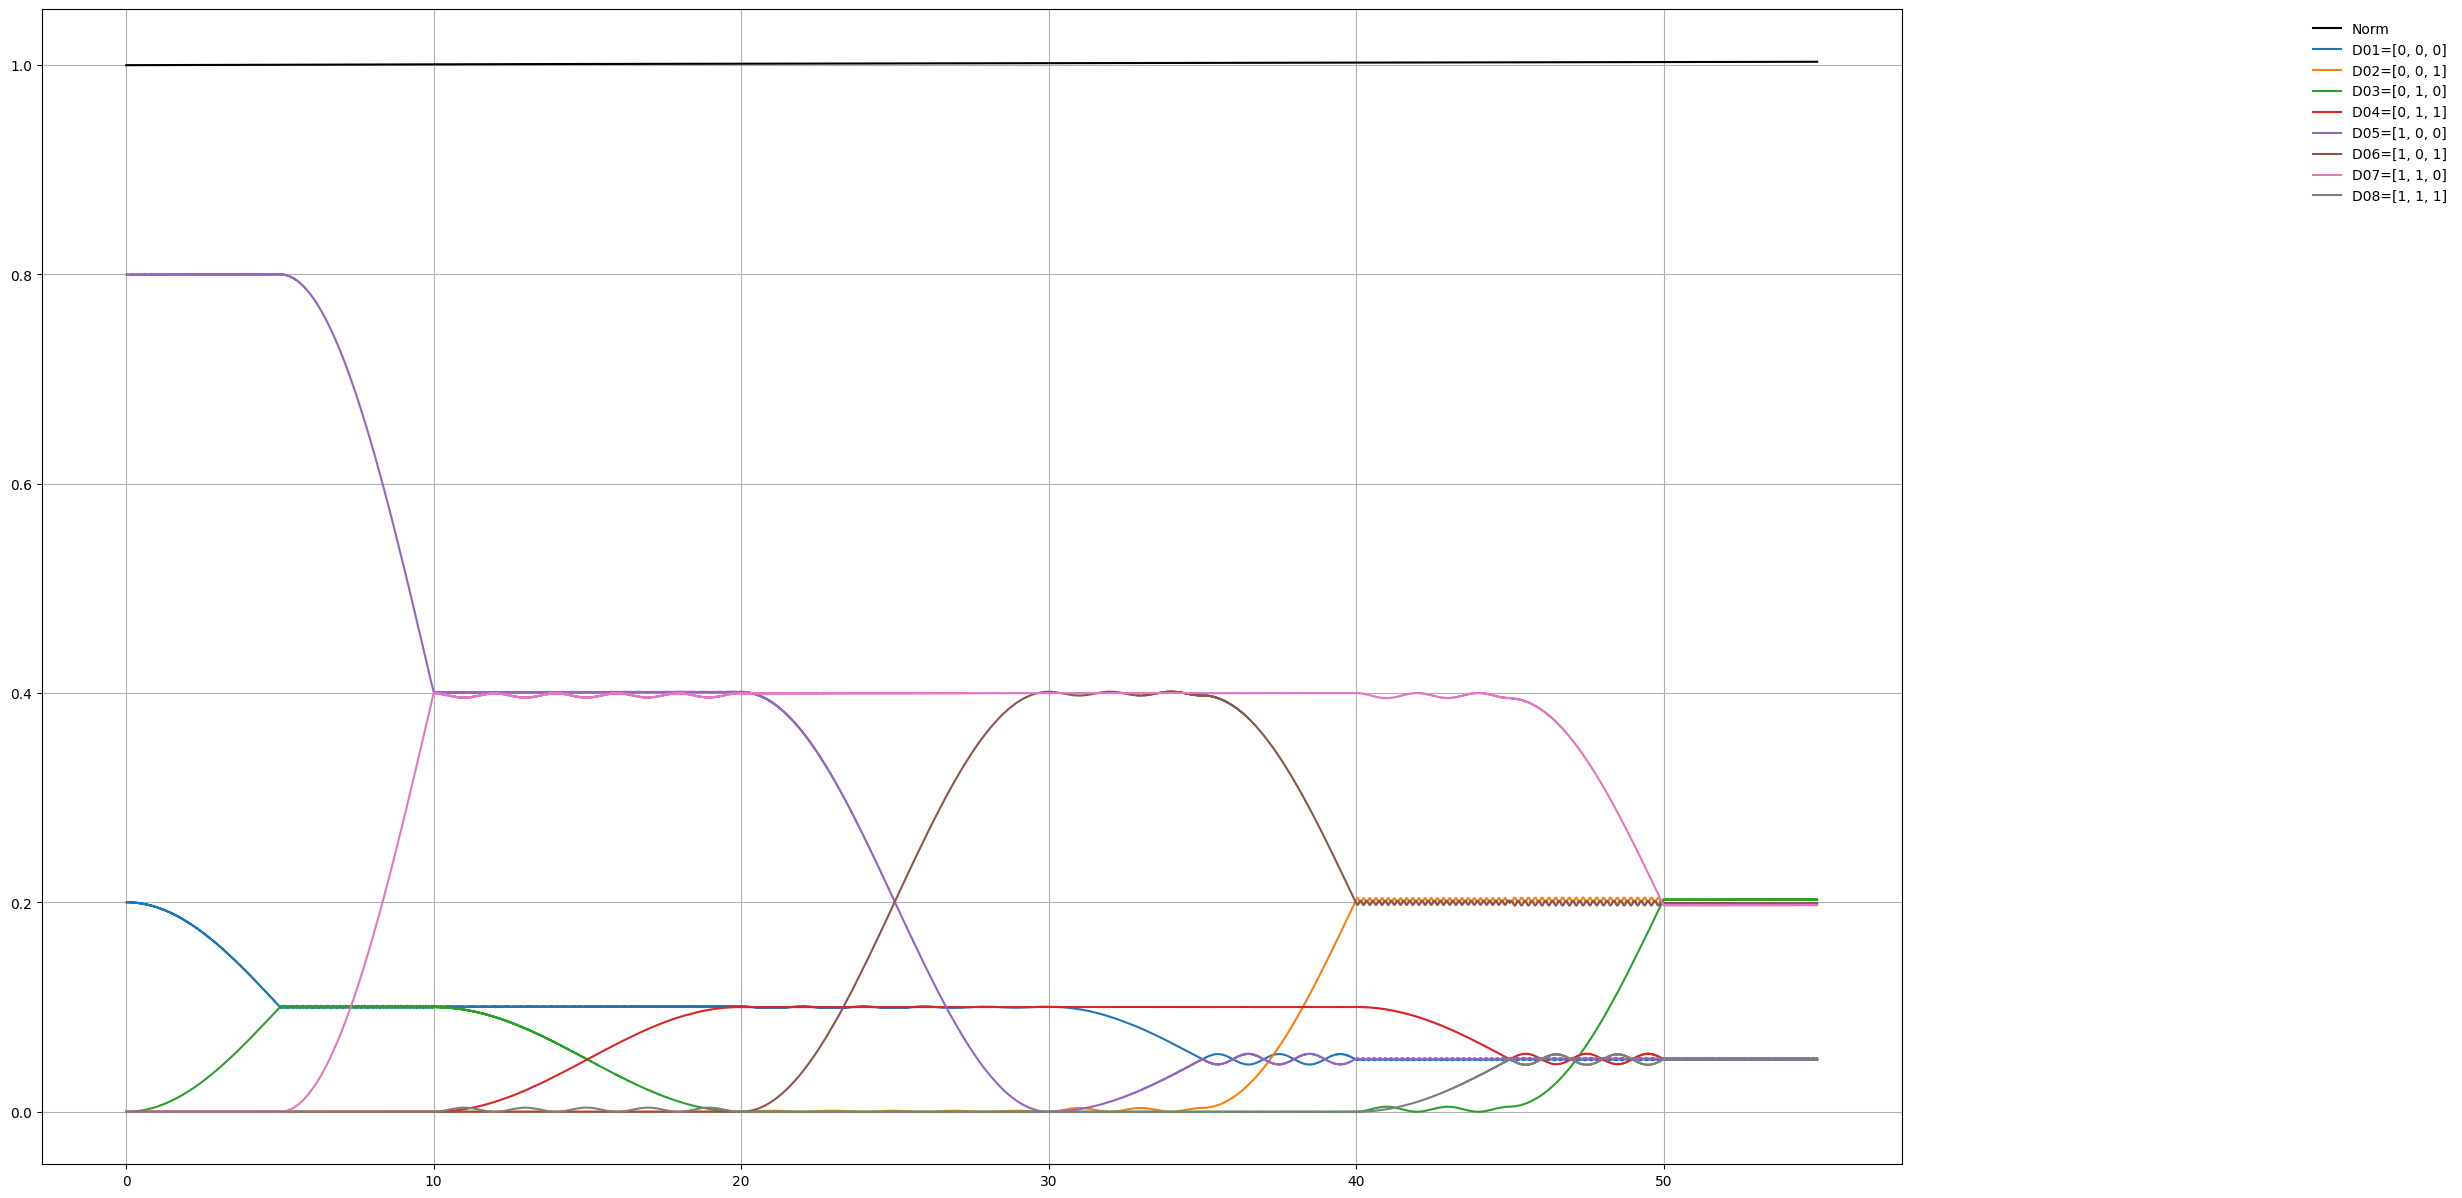

In [5]:
plt.figure(figsize = (30,15))

plt.plot(T,N, label="Norm", color='k')
if QUBITS_NB <= 4:
    for l in range(num_states):
        if l+1<10:
            plt.plot(T,D[l+1],label=f'D0{l+1}={all_states_dict[l+1]}')
        else:
            plt.plot(T,D[l+1],label=f'D{l+1}={all_states_dict[l+1]}')

if QUBITS_NB > 4:
    for l in range(num_states):
        if l+1<10:
            plt.plot(T,D[l+1], label=str(l+1))
        else:
            plt.plot(T,D[l+1], label=str(l+1))

fig = plt.gcf()
ax = plt.subplot(111)
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width*0.8, box.height])
plt.legend(loc=1, bbox_to_anchor=(1.3, 1.0), frameon=False)
plt.grid()
plt.show()

In [35]:
def plot_helper(val):
    fig = plt.figure(figsize=(5, 8))
    ax = fig.add_subplot(2, 1, 1)
    ax2 = fig.add_subplot(2, 1, 2, projection="3d")
    qubit_probabilities = get_qubit_probabilities(val)
    plotting_val(val, ax)
    plot_qubits_proba(qubit_probabilities, ax2)
    plt.tight_layout()
    
#fig.suptitle('A tale of 2 subplots')

2
102
202
302
402
502
602
702
802
902
1002
1102
1202
1302
1402
1502
1602
1702
1802
1902
2002
2102
2202
2302
2402
2502
2602
2702
2802
2902
3002
3102
3202
3302
3402
3502
3602
3702
3802
3902
4002
4102
4202
4302
4402
4502
4602
4702
4802
4902
5002
5102
5202
5302
5402
5502
5602
5702
5802
5902
6002
6102
6202
6302
6402
6502
6602
6702
6802
6902
7002
7102
7202
7302
7402
7502
7602
7702
7802
7902
8002
8102
8202
8302
8402
8502
8602
8702
8802
8902
9002
9102
9202
9302
9402
9502
9602
9702
9802
9902
10002
10102
10202
10302
10402
10502
10602
10702
10802
10902


IndexError: index 11002 is out of bounds for axis 0 with size 11000

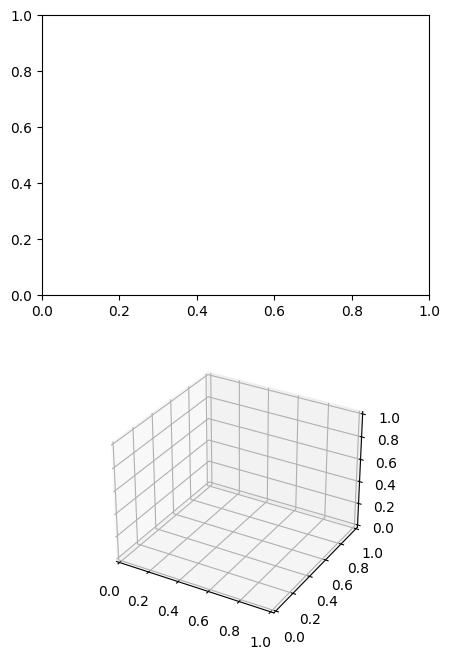

In [38]:
step = 100
for elements in range(0+2, len(T)+step, step):
    plot_helper(val=elements)
    print(elements)
    plt.savefig(f'../results/quantum_teleportation_3q_images/img_{str(elements).zfill(5)}')
    plt.close()


In [39]:
save_gif('quantum_teleportation_3q_images', 'quantum_teleportation_3q')